In [49]:
# import gurobipy as gp
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.io as pio
import numpy as np
import pandas as pd

Loading Network

In [50]:
def load_edges_from_csv(path_edges: str):
    """
    CSV esperado: node_id1,node_id2,b,f_max
    b = costo base por arco
    f_max = capacidad base
    """
    edges = pd.read_csv(path_edges)
    edges = edges.rename(columns={
        "node_id1": "i",
        "node_id2": "j",
        "b": "c_base",
        "f_max": "U_base"
    })

    edges["e_id"] = np.arange(len(edges))
    return edges

def load_nodes_from_csv(path_nodes: str):
    """
    CSV esperado:
    node_id,d,p_min,p_max,c_var,is_generator,energy_type,instance
    d = demanda base (si no es generador)
    p_max = capacidad gen máxima (si es generador)
    """
    nodes = pd.read_csv(path_nodes)
    nodes = nodes.rename(columns={"node_id":"node"})
    return nodes

Defining the world $W$, the baseline for scenarios

In [51]:
def sample_one_scenario_W(nodes, edges, rng,
                          p_crisis=0.15,
                          # mediocristan
                          dem_sigma=0.10,
                          cost_sigma=0.05,
                          p_outage=0.15,
                          cap_drop=0.65,
                          # extremistan
                          crisis_dem_mult_mu=2.0,
                          crisis_dem_mult_sigma=0.25,
                          crisis_cost_mult=1.25,
                          correlated_outage_nodes=None,
                          correlated_outage_prob=0.65):

    # 1) Crisis o no
    crisis = rng.random() < p_crisis

    # 2) Demanda por nodo: D_iω
    D = nodes[["node"]].copy()
    D["D_base"] = nodes["d"].fillna(0.0)

    if not crisis:
        mult = rng.normal(1.0, dem_sigma, size=len(D))
        mult = np.clip(mult, 0.0, None)
    else:
        pareto_alpha = 2.5
        Y = rng.pareto(a=pareto_alpha, size=len(D))
        mult = 1.0 + Y

    D["D_w"] = D["D_base"] * mult
    D.loc[D["D_base"] == 0, "D_w"] = 0.0

    # 3) Costo por arco: c_eω
    c = edges[["e_id", "c_base"]].copy()

    if not crisis:
        cost_mult = rng.normal(1.0, cost_sigma, size=len(c))
        cost_mult = np.clip(cost_mult, 0.1, None)
    else:
        cost_mult = np.ones(len(c)) * crisis_cost_mult
    c["c_w"] = c["c_base"] * cost_mult

    # 4) Capacidad por arco: U_eω
    U = edges[["e_id", "U_base", "i", "j"]].copy()

    outage = rng.random(len(U)) < p_outage
    U_mult = np.where(outage, cap_drop, 1.0)

    if crisis and correlated_outage_nodes is not None:
        if rng.random() < correlated_outage_prob:
            affected = U["i"].isin(correlated_outage_nodes) | U["j"].isin(correlated_outage_nodes)
            U_mult = np.where(affected, 0.0, U_mult)

    U["U_w"] = U["U_base"] * U_mult

    # 5) Capacidad de generación por nodo: G_iω  ← NUEVO
    G = nodes[["node"]].copy()
    G["G_base"] = nodes["p_max"].fillna(0.0)

    if not crisis:
        gen_mult = rng.normal(1.0, 0.05, size=len(G))
        gen_mult = np.clip(gen_mult, 0.5, 1.0)
    else:
        gen_mult = rng.uniform(0.3, 1.0, size=len(G))

    G["G_w"] = G["G_base"] * gen_mult
    G.loc[G["G_base"] == 0, "G_w"] = 0.0  # nodos de demanda no generan

    return {
        "crisis": int(crisis),
        "D": D[["node", "D_w"]],
        "U": U[["e_id", "U_w"]],
        "c": c[["e_id", "c_w"]],
        "G": G[["node", "G_w"]],   # ← NUEVO
    }

Montecarlo simulation

In [52]:

def generate_massive_W(nodes, edges, n_samples=1000, seed=123,
                       correlated_outage_nodes=None):
    rng = np.random.default_rng(seed)
    scenarios = []
    for _ in range(n_samples):
        sc = sample_one_scenario_W(nodes, edges, rng,
                                   correlated_outage_nodes=correlated_outage_nodes)
        scenarios.append(sc)
    return scenarios


Clustering process

In [53]:
def scenario_features(sc, nodes, edges):
    """
    Convierte escenario a un vector feature para cluster:
    - demanda total
    - % capacidad perdida (promedio)
    - costo medio
    - indicador crisis
    """
    Dtot = sc["D"]["D_w"].sum()

    U_base = edges.set_index("e_id")["U_base"]
    U_eff  = sc["U"].set_index("e_id")["U_w"]
    cap_loss = 1.0 - (U_eff / U_base.replace(0, np.nan)).fillna(1.0)
    cap_loss_mean = cap_loss.mean()

    c_mean = sc["c"]["c_w"].mean()

    return np.array([Dtot, cap_loss_mean, c_mean, sc["crisis"]], dtype=float)

def reduce_to_K_scenarios(scenarios, nodes, edges, K=20, seed=123):
    """
    Reducción simple:
    - extrae features
    - aplica k-means
    - elige como representante el escenario más cercano al centroide (medoid)
    - prob de cada escenario = proporción de puntos asignados
    """
    from sklearn.cluster import KMeans

    X = np.vstack([scenario_features(sc, nodes, edges) for sc in scenarios])
    km = KMeans(n_clusters=K, random_state=seed, n_init=20)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    reps = []
    probs = []
    #encontrar representante de cada cluster
    for k in range(K):
        idx = np.where(labels == k)[0]
        probs.append(len(idx) / len(scenarios))
        # elegir el más cercano al centroide
        dists = np.linalg.norm(X[idx] - centers[k], axis=1)
        rep_idx = idx[np.argmin(dists)]
        reps.append(scenarios[rep_idx])

    return reps, np.array(probs)

In [54]:
def export_Wprime(reps, probs, out_prefix="Wprime"):
    """
    Crea tres tablas:
    - demanda: (omega, node, D_iw)
    - capacidad: (omega, e_id, U_ew)
    - costos: (omega, e_id, c_ew)
    - prob: (omega, p_omega, crisis)
    """
    rows_D, rows_U, rows_c, rows_p, rows_G = [], [], [], [], []

    for w, (sc, p) in enumerate(zip(reps, probs), start=1):
        rows_p.append({"omega": w, "p_omega": float(p), "crisis": sc["crisis"]})

        for _, r in sc["D"].iterrows():
            rows_D.append({"omega": w, "node": int(r["node"]), "D_iw": float(r["D_w"])})
        for _, r in sc["U"].iterrows():
            rows_U.append({"omega": w, "e_id": int(r["e_id"]), "U_ew": float(r["U_w"])})
        for _, r in sc["c"].iterrows():
            rows_c.append({"omega": w, "e_id": int(r["e_id"]), "c_ew": float(r["c_w"])})
        for _, r in sc["G"].iterrows():
            rows_G.append({"omega": w, "node": int(r["node"]), "G_iw": float(r["G_w"])})

    dfD = pd.DataFrame(rows_D)
    dfU = pd.DataFrame(rows_U)
    dfc = pd.DataFrame(rows_c)
    dfp = pd.DataFrame(rows_p)
    dfG = pd.DataFrame(rows_G)

    dfD.to_csv(f"{out_prefix}_D.csv", index=False)
    dfU.to_csv(f"{out_prefix}_U.csv", index=False)
    dfc.to_csv(f"{out_prefix}_c.csv", index=False)
    dfp.to_csv(f"{out_prefix}_p.csv", index=False)
    dfG.to_csv(f"{out_prefix}_G.csv", index=False)

    return dfD, dfU, dfc, dfp, dfG


In [55]:
edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

instance = 69
nodes = nodes[nodes["instance"] == instance].reset_index(drop=True)
gens = nodes[nodes["is_generator"] == True]["node"].to_list()

print("Instancia elegida:", instance)
print("nodos totales:", len(nodes))
print("generadores:", gens)
print("Tipo de energía para la instancia", instance, ":")
print(nodes.groupby("energy_type")["node"].count())

# 1) W masivo
escenarios_W = generate_massive_W(nodes, edges, n_samples=1000, seed=1,
                                  correlated_outage_nodes=gens)

# 2) Reducir a 20 escenarios
reps, probs = reduce_to_K_scenarios(escenarios_W, nodes, edges, K=20, seed=1)

# 3) Exportar — ahora retorna 5 valores (dfG es nuevo)
dfD, dfU, dfc, dfp, dfG = export_Wprime(reps, probs, out_prefix="Wprime20")

Instancia elegida: 69
nodos totales: 118
generadores: [9, 11, 24, 25, 30, 45, 48, 53, 58, 60, 64, 65, 79, 86, 88, 99, 102, 110]
Tipo de energía para la instancia 69 :
energy_type
coal     4
gas      6
hydro    2
solar    4
wind     2
Name: node, dtype: int64


c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


## Resumen de la instancia seleccionada


\begin{array}{ll}
\textbf{Instancia elegida} & 69 \\
\textbf{Número total de nodos} & 118 \\
\textbf{Número de generadores} & 18 \\
\textbf{Nodos generadores} & [9, 11, 24, 25, 30, 45, 48, 53, 58, 60, 64, 65, 79, 86, 88, 99, 102, 110]
\end{array}


### Tipo de energía por generador


\begin{array}{lc}
\textbf{Tipo de energía} & \textbf{Número de generadores} \\
\hline
\text{coal} & 4 \\
\text{gas} & 6 \\
\text{hydro} & 2 \\
\text{solar} & 4 \\
\text{wind} & 2
\end{array}


In [56]:
# nodes
# dfD[dfD["omega"]==1]
dfp["p_omega"].sum()

np.float64(1.0)

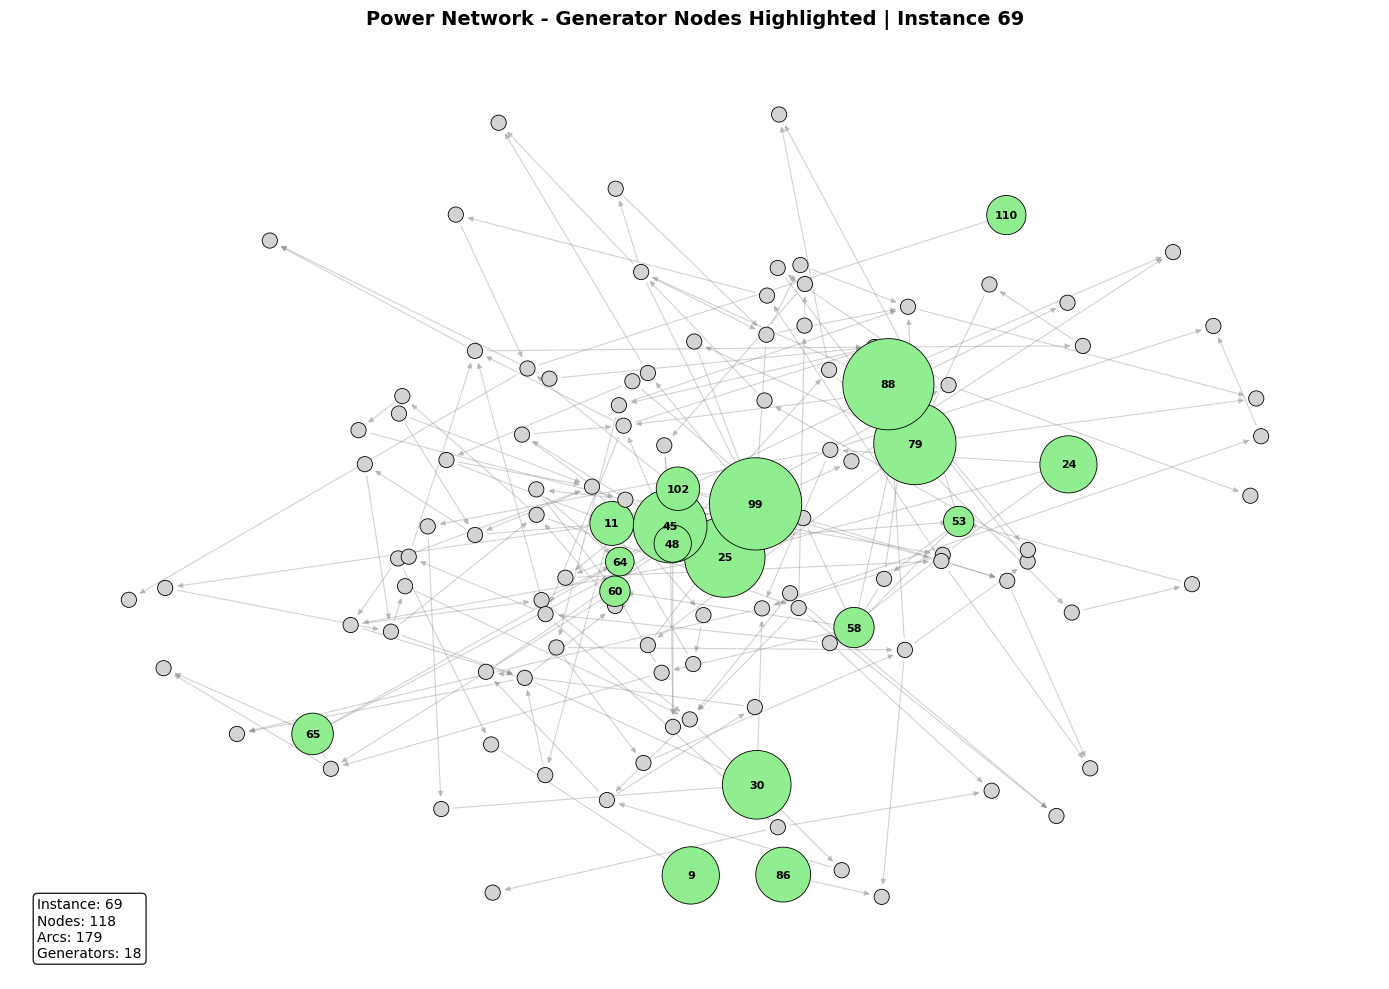

In [57]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.DiGraph()

for n in nodes["node"].unique():
    G.add_node(n)

for _, row in edges.iterrows():
    G.add_edge(row["i"], row["j"], e_id=row["e_id"])


gen_nodes = nodes[nodes["is_generator"] == True].copy()
gen_capacity = dict(zip(gen_nodes["node"], gen_nodes["p_max"]))

node_sizes = []
node_colors = []

for n in G.nodes():
    if n in gen_capacity:
        size = 300 + 3.5 * gen_capacity.get(n, 0)
        node_sizes.append(size)
        node_colors.append("lightgreen")
    else:
        node_sizes.append(120)
        node_colors.append("lightgray")


pos = nx.spring_layout(G, seed=42, k=0.35)

plt.figure(figsize=(14, 10))

# Edges
nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    alpha=0.35,
    arrows=True,
    arrowsize=8,
    width=0.8
)

# Nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=0.6
)

# Labels only for generators
gen_labels = {n: str(n) for n in gens}
nx.draw_networkx_labels(
    G,
    pos,
    labels=gen_labels,
    font_size=8,
    font_weight="bold"
)

plt.title(
    f"Power Network - Generator Nodes Highlighted | Instance {instance}",
    fontsize=14,
    fontweight="bold"
)


table_text = (
    f"Instance: {instance}\n"
    f"Nodes: {len(nodes)}\n"
    f"Arcs: {len(edges)}\n"
    f"Generators: {len(gens)}"
)

plt.text(
    0.02,
    0.02,
    table_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.axis("off")
plt.tight_layout()
plt.show()

Gráficos

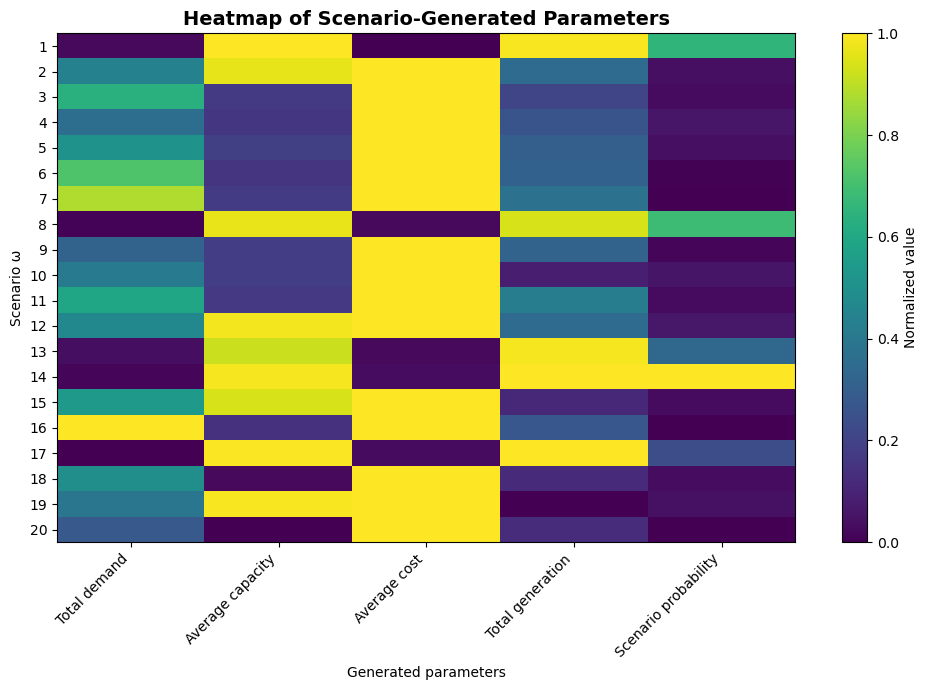

,Total demand,Average capacity,Average cost,Total generation,Scenario probability
omega,,,,,
1,3276.814060,441.706983,19.412068,7585.290415,0.191
2,5158.100590,434.804749,24.373063,5335.677941,0.013
3,6057.131420,281.982961,24.373063,4835.030578,0.009
4,4817.350333,280.101955,24.373063,5024.498152,0.019
5,5510.295254,286.308101,24.373063,5173.621808,0.013
6,6470.685322,278.711732,24.373063,5193.790290,0.003
7,7182.845038,283.308659,24.373063,5417.761543,0.001
8,3202.684993,435.152793,19.535769,7414.153304,0.200
9,4605.570351,284.814246,24.373063,5224.297969,0.006


In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# Aggregate scenario parameters
# -------------------------
scenario_summary = pd.DataFrame({"omega": dfp["omega"]})

# Total demand per scenario
demand_agg = (
    dfD.groupby("omega")["D_iw"]
    .sum()
    .reset_index()
    .rename(columns={"D_iw": "Total demand"})
)

# Average effective capacity per scenario
capacity_agg = (
    dfU.groupby("omega")["U_ew"]
    .mean()
    .reset_index()
    .rename(columns={"U_ew": "Average capacity"})
)

# Average operational cost per scenario
cost_agg = (
    dfc.groupby("omega")["c_ew"]
    .mean()
    .reset_index()
    .rename(columns={"c_ew": "Average cost"})
)

# Total generation per scenario
generation_agg = (
    dfG.groupby("omega")["G_iw"]
    .sum()
    .reset_index()
    .rename(columns={"G_iw": "Total generation"})
)

# Probabilities
prob_agg = (
    dfp[["omega", "p_omega"]]
    .rename(columns={"p_omega": "Scenario probability"})
)

# Merge everything
scenario_summary = (
    scenario_summary
    .merge(demand_agg, on="omega", how="left")
    .merge(capacity_agg, on="omega", how="left")
    .merge(cost_agg, on="omega", how="left")
    .merge(generation_agg, on="omega", how="left")
    .merge(prob_agg, on="omega", how="left")
)

scenario_summary = scenario_summary.set_index("omega")

# -------------------------
# Normalize columns for heatmap
# -------------------------
heatmap_data = scenario_summary.copy()

heatmap_norm = (heatmap_data - heatmap_data.min()) / (
    heatmap_data.max() - heatmap_data.min()
)

# -------------------------
# Plot heatmap
# -------------------------
plt.figure(figsize=(10, 7))

plt.imshow(
    heatmap_norm.values,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Normalized value")

plt.xticks(
    ticks=np.arange(len(heatmap_norm.columns)),
    labels=heatmap_norm.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(heatmap_norm.index)),
    labels=heatmap_norm.index
)

plt.title(
    "Heatmap of Scenario-Generated Parameters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Generated parameters")
plt.ylabel("Scenario ω")

plt.tight_layout()
plt.show()

display(scenario_summary)

The heatmap summarizes the main generated parameters for each reduced scenario $\omega$. Each column is normalized to allow comparison across variables with different units. Higher values indicate scenarios with larger demand, higher operational costs, greater generation availability, or larger effective capacities. This visualization helps identify which scenarios correspond to normal operating conditions and which scenarios represent stressed or extreme states of the system.

In [59]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Patch

omegas_list = dfp["omega"].tolist()
p_vals      = dfp["p_omega"].values
crisis_vals = dfp["crisis"].values
colors      = ["#c0392b" if c else "#2980b9" for c in crisis_vals]
labels      = [f"ω{w}" for w in omegas_list]

D_total   = dfD.groupby("omega")["D_iw"].sum().reindex(omegas_list).values
c_mean_sc = dfc.groupby("omega")["c_ew"].mean().reindex(omegas_list).values
G_total   = dfG.groupby("omega")["G_iw"].sum().reindex(omegas_list).values
deficit   = D_total - G_total

U_base_series = edges.set_index("e_id")["U_base"]
cap_loss_mean, arcos_caidos, arcos_debil = [], [], []
for w in omegas_list:
    U_sc  = dfU[dfU["omega"] == w].set_index("e_id")["U_ew"]
    ratio = (U_sc / U_base_series.replace(0, np.nan)).fillna(1.0)
    loss  = 1.0 - ratio
    cap_loss_mean.append(loss.mean())
    arcos_caidos.append((U_sc == 0).sum())
    arcos_debil.append(((U_sc > 0) & (U_sc < U_base_series)).sum())

cap_loss_mean = np.array(cap_loss_mean)
arcos_caidos  = np.array(arcos_caidos)
arcos_debil   = np.array(arcos_debil)

legend_elements = [
    Patch(facecolor="#c0392b", label="Crisis (Extremistán)"),
    Patch(facecolor="#2980b9", label="Normal (Mediocristán)"),
]

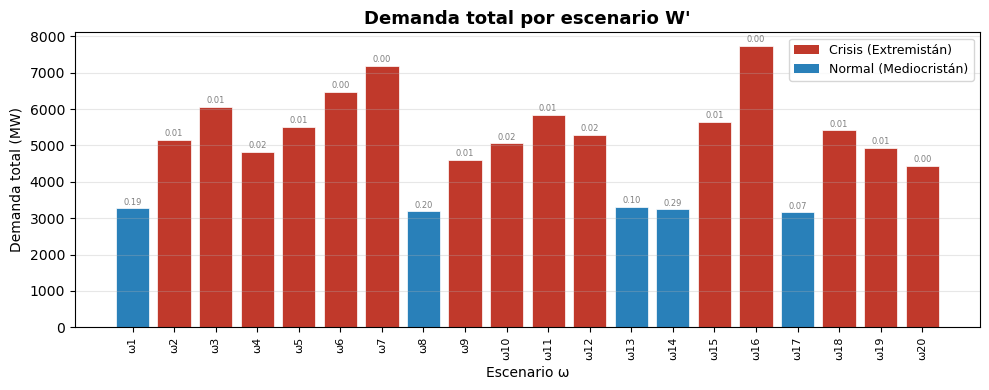

In [60]:
# Demanda total por escenario

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(labels, D_total, color=colors, edgecolor="white", linewidth=0.5)
for bar, p in zip(bars, p_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{p:.2f}", ha="center", va="bottom", fontsize=6, color="gray")

ax.set_title("Demanda total por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Demanda total (MW)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

The total demand per scenario shows a clear separation between normal and crisis regimes. Normal scenarios (Mediocristán) present moderate demand levels, while crisis scenarios (Extremistán) exhibit significantly higher total demand. This reflects the heavy-tail behavior introduced in the scenario generator, where extreme events produce large demand spikes that stress the network and create potential supply shortages.

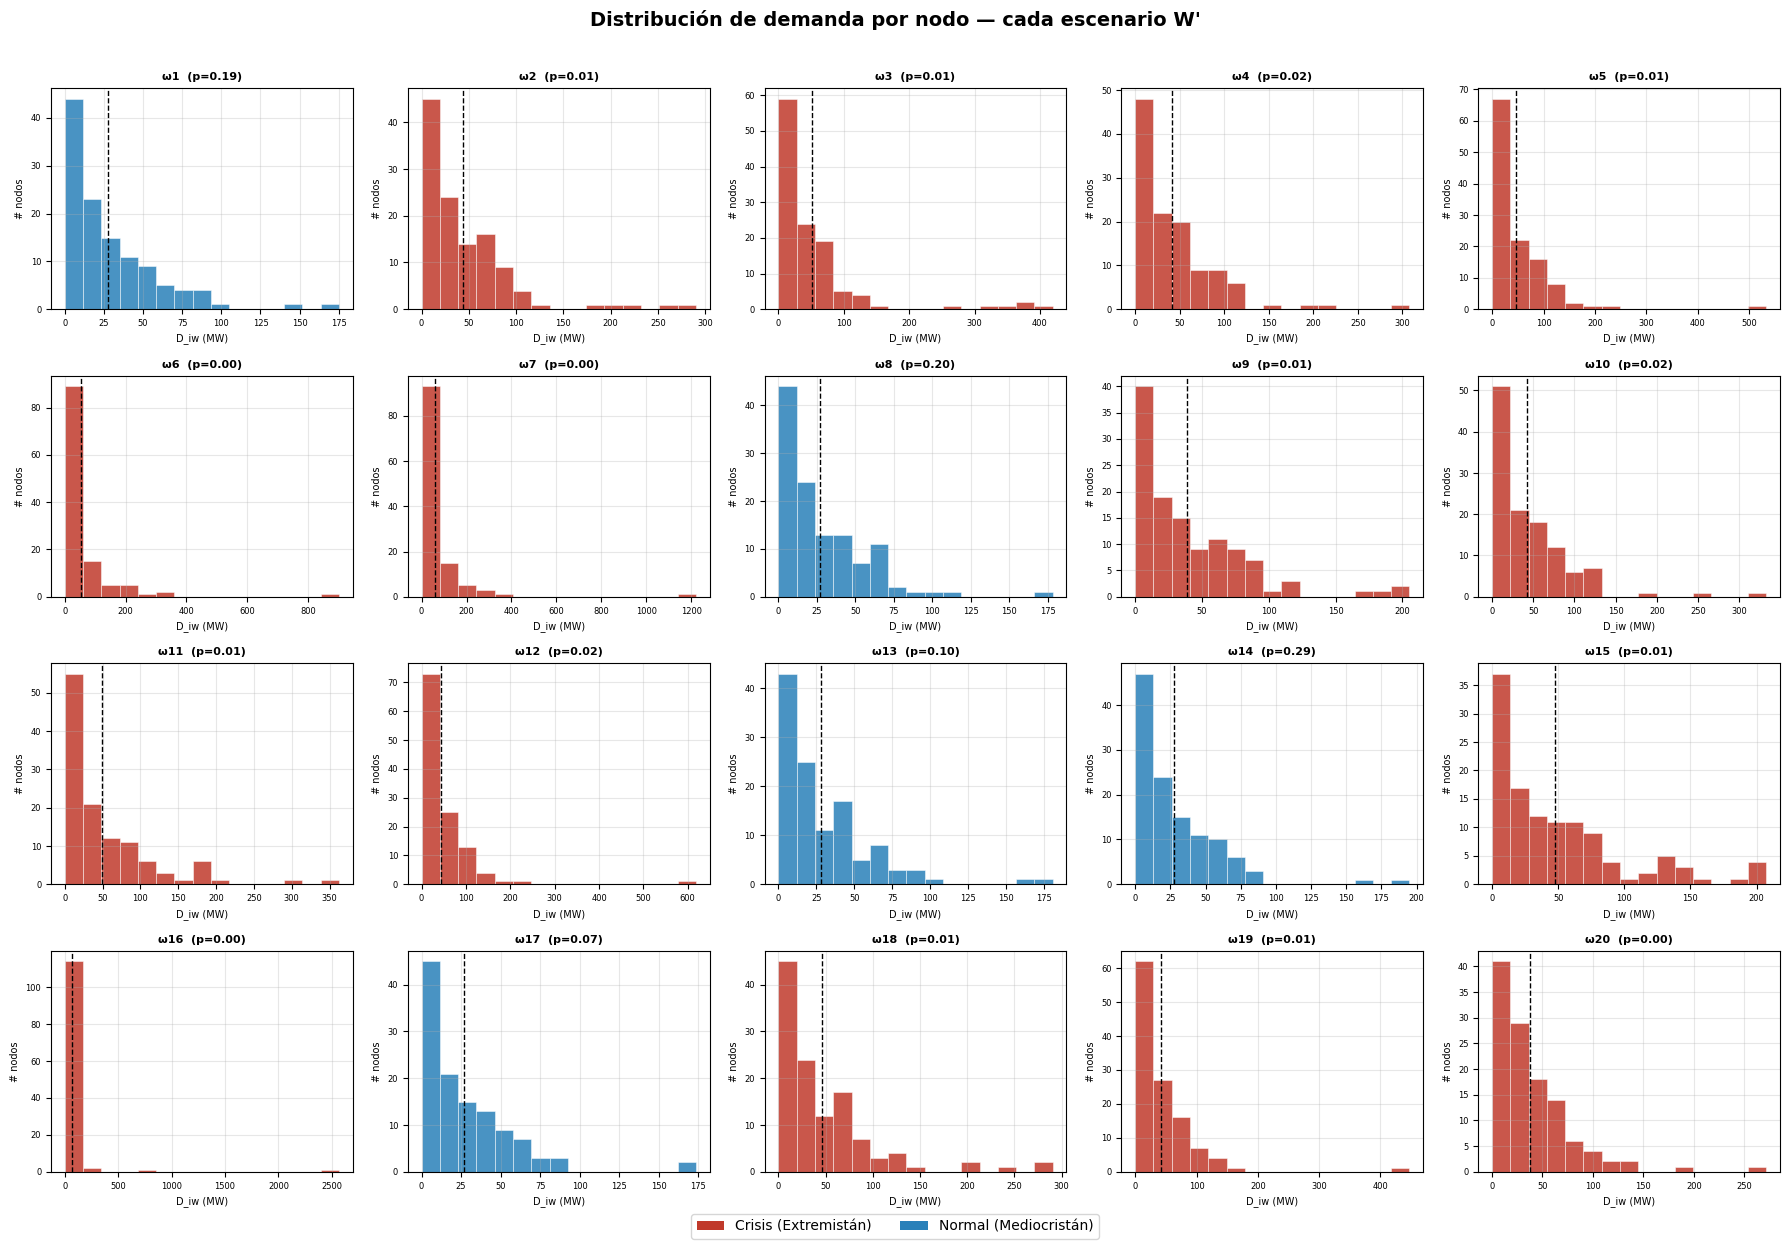

In [61]:
#Demanda

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals = dfD[dfD["omega"] == w]["D_iw"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#2980b9"

    ax.hist(vals, bins=15, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("D_iw (MW)", fontsize=7)
    ax.set_ylabel("# nodos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de demanda por nodo — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
fig.legend(handles=legend_elements, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

The node-level demand distributions reveal strong skewness across scenarios. In crisis scenarios, the histograms show long right tails, indicating that a few nodes experience extremely high demand values. In contrast, normal scenarios remain concentrated around lower values. This confirms that demand uncertainty follows a heavy-tailed pattern, where rare scenarios generate very large loads at certain nodes.

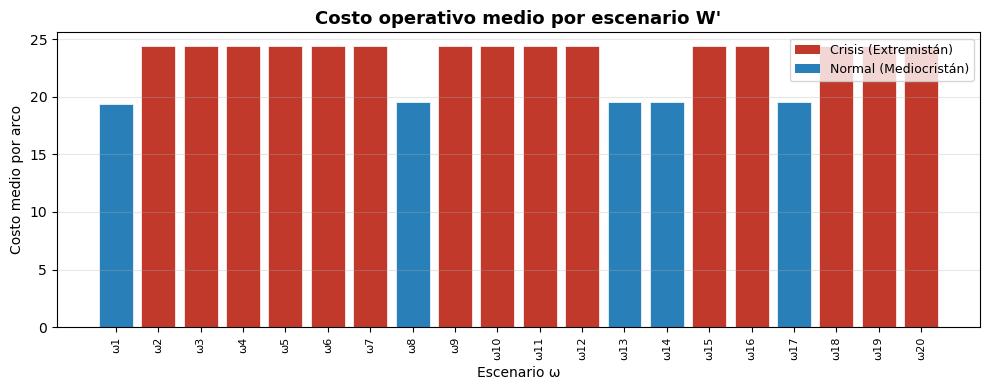

In [62]:
# Costo operativo medio por escenario

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, c_mean_sc, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Costo operativo medio por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Costo medio por arco")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

The average operational cost per arc increases significantly in crisis scenarios compared with normal scenarios. This occurs because crisis regimes apply higher cost multipliers, reflecting financial stress or operational inefficiencies during disruptions. As a result, extreme scenarios not only increase demand but also make power transmission more expensive.

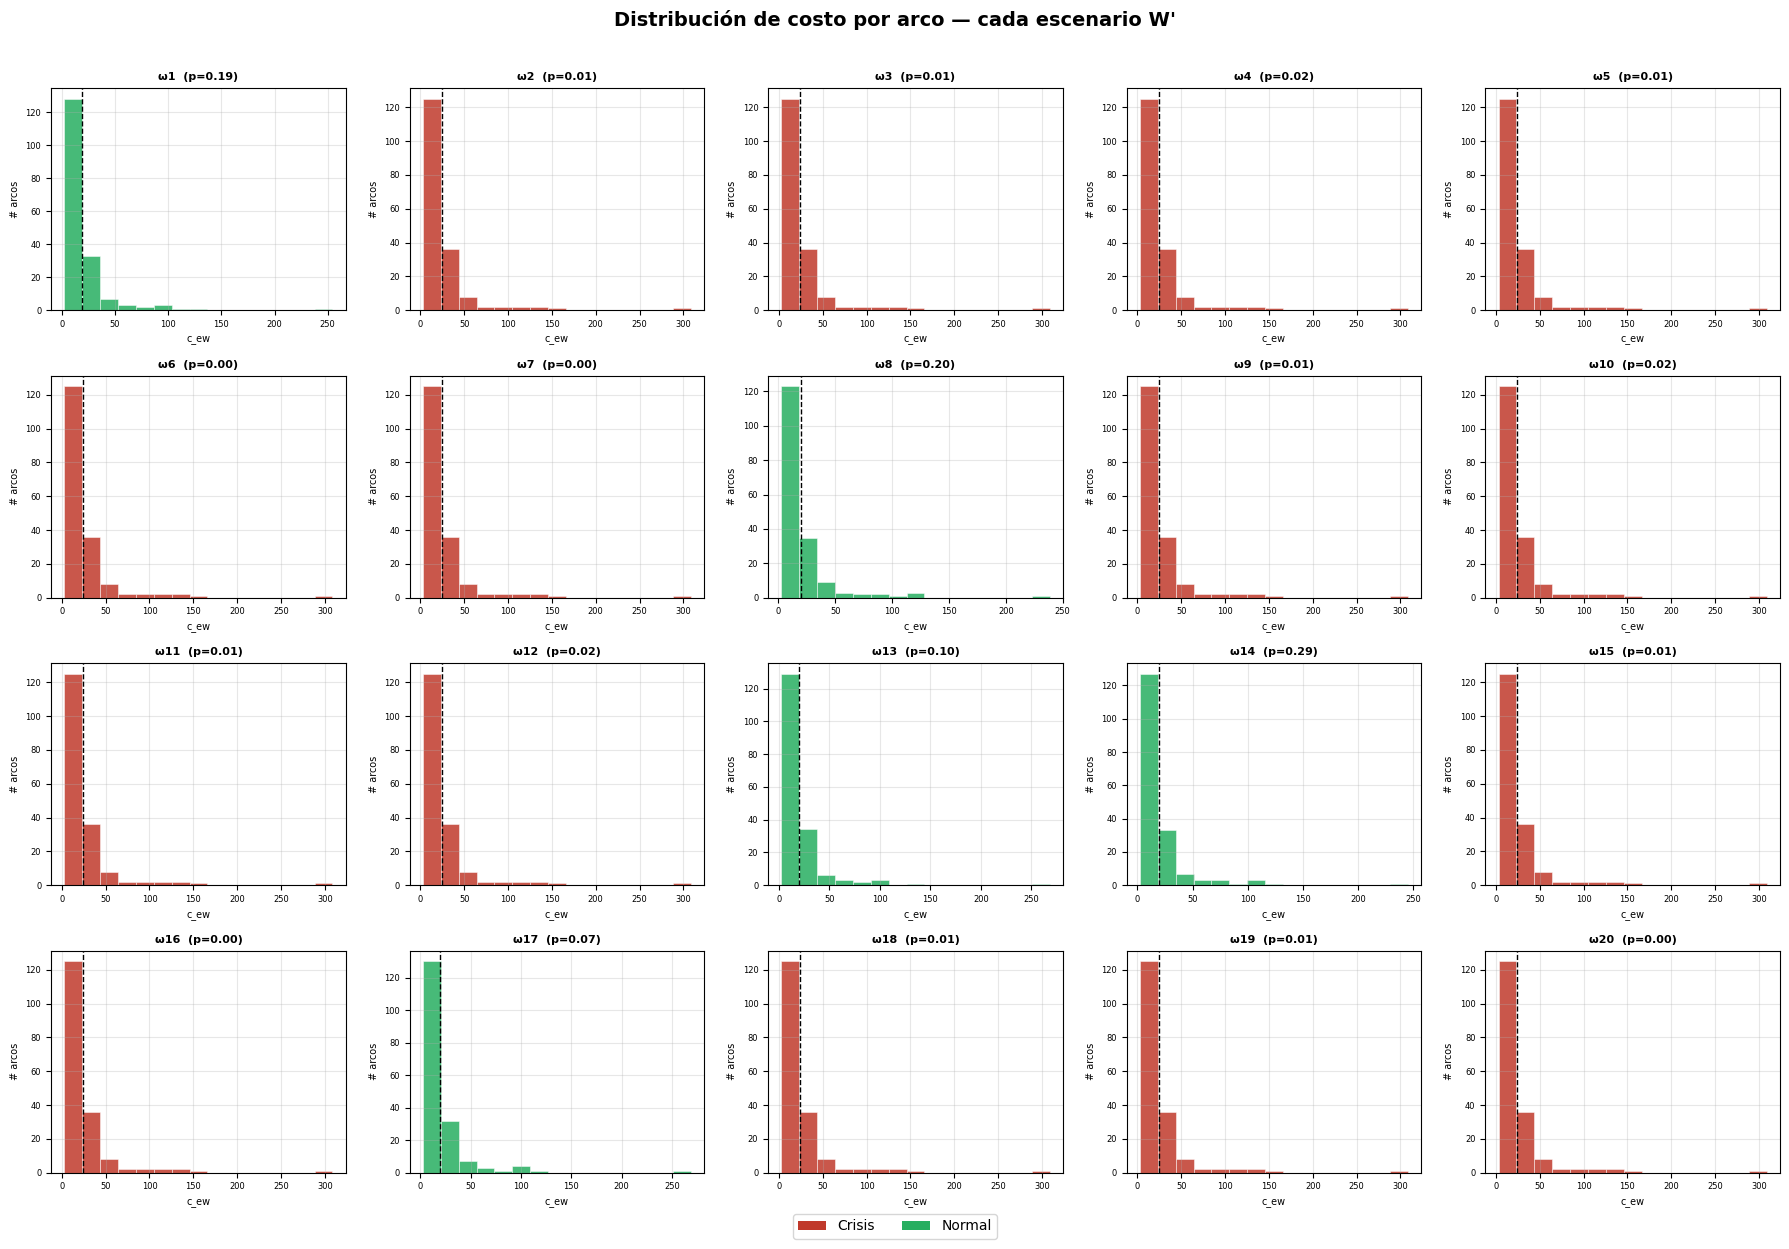

In [63]:
# Costo por escenario

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals = dfc[dfc["omega"] == w]["c_ew"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#27ae60"

    ax.hist(vals, bins=15, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("c_ew", fontsize=7)
    ax.set_ylabel("# arcos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de costo por arco — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
cost_legend = [Patch(facecolor="#c0392b", label="Crisis"),
               Patch(facecolor="#27ae60", label="Normal")]
fig.legend(handles=cost_legend, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

The average operational cost per arc increases significantly in crisis scenarios compared with normal scenarios. This occurs because crisis regimes apply higher cost multipliers, reflecting financial stress or operational inefficiencies during disruptions. As a result, extreme scenarios not only increase demand but also make power transmission more expensive.

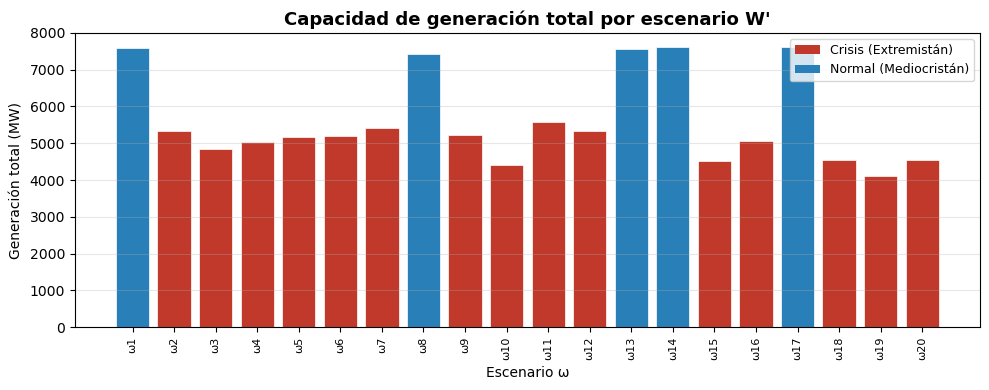

In [64]:
# Capacidad por escenario
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, G_total, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Capacidad de generación total por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Generación total (MW)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

The total available generation per scenario remains relatively stable across scenarios but is slightly lower in crisis conditions.

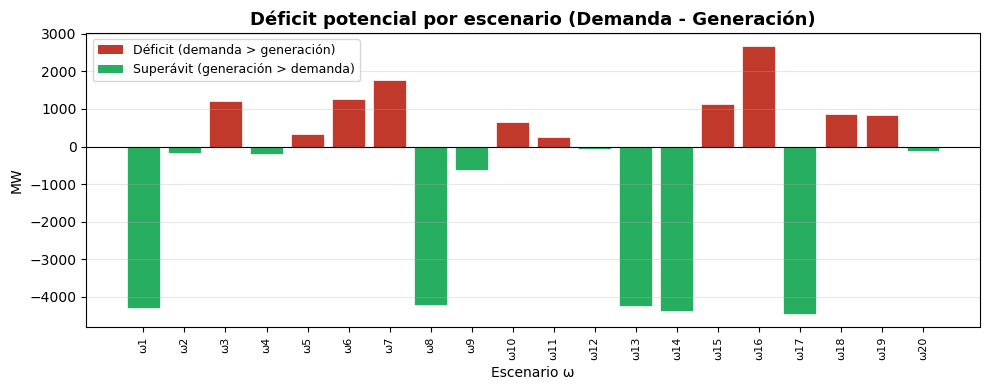

In [65]:
# Deficit potencial por escenario

fig, ax = plt.subplots(figsize=(10, 4))

deficit_colors = ["#c0392b" if d > 0 else "#27ae60" for d in deficit]
ax.bar(labels, deficit, color=deficit_colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Déficit potencial por escenario (Demanda - Generación)", fontsize=13, fontweight="bold")
ax.set_ylabel("MW")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)

deficit_legend = [
    Patch(facecolor="#c0392b", label="Déficit (demanda > generación)"),
    Patch(facecolor="#27ae60", label="Superávit (generación > demanda)"),
]
ax.legend(handles=deficit_legend, fontsize=9)
plt.tight_layout()
plt.show()

The deficit plot highlights the imbalance between demand and generation in each scenario. Positive values indicate scenarios where demand exceeds generation capacity, leading to potential load shedding. Crisis scenarios tend to produce larger deficits, while some normal scenarios show negative values.

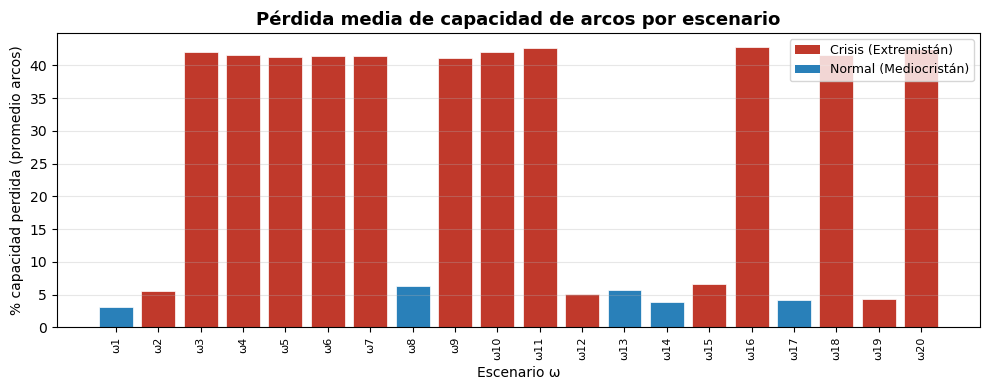

In [66]:
# Pérdida de capacidad por escenario

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, cap_loss_mean * 100, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Pérdida media de capacidad de arcos por escenario", fontsize=13, fontweight="bold")
ax.set_ylabel("% capacidad perdida (promedio arcos)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

The deficit plot highlights the imbalance between demand and generation in each scenario. Positive values indicate scenarios where demand exceeds generation capacity, leading to potential load shedding. Crisis scenarios tend to produce larger deficits, while some normal scenarios show negative values

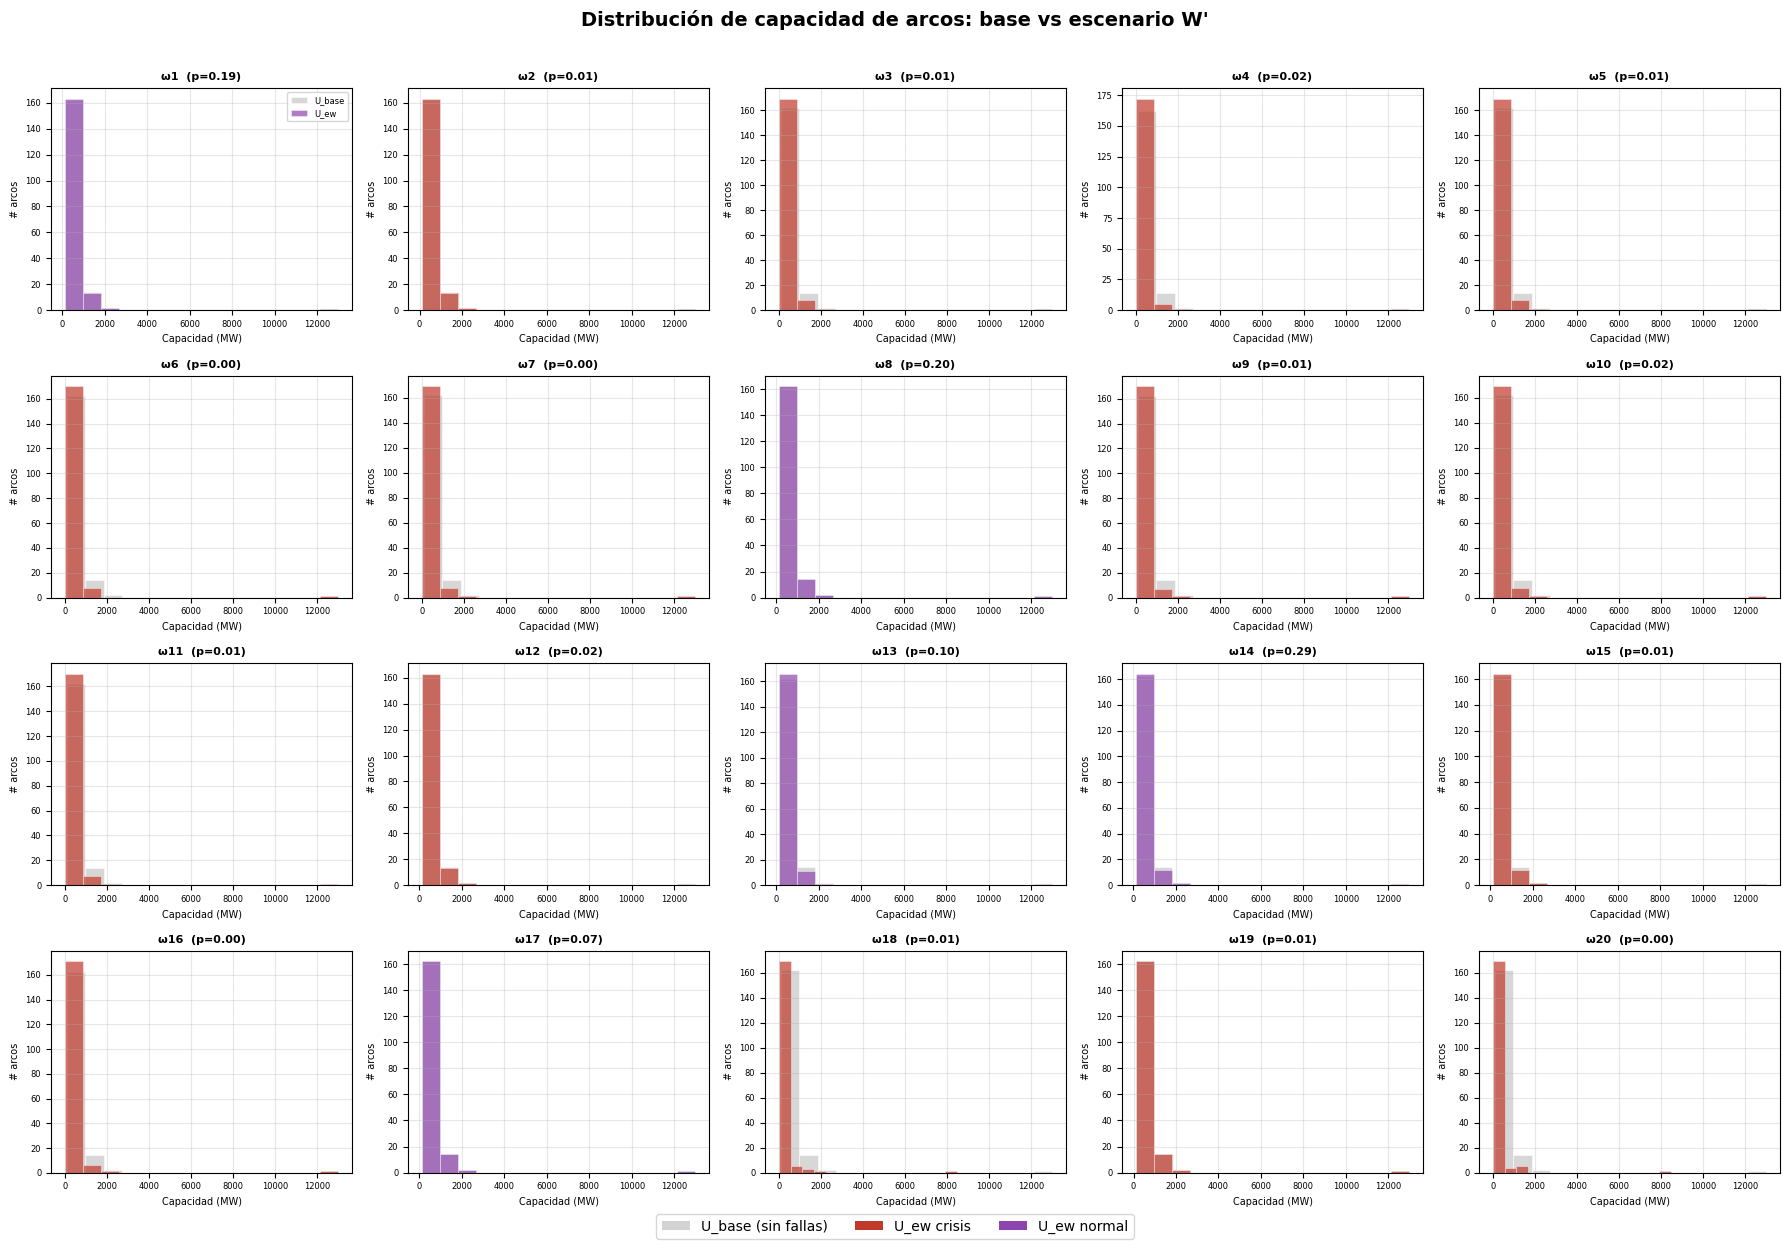

In [67]:
# Capacidad de arcos

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals      = dfU[dfU["omega"] == w]["U_ew"].values
    vals_base = U_base_series.values
    crisis    = dfp[dfp["omega"] == w]["crisis"].values[0]
    color     = "#c0392b" if crisis else "#8e44ad"

    ax.hist(vals_base, bins=15, color="lightgray", edgecolor="white",
            linewidth=0.4, alpha=0.9, label="U_base")
    ax.hist(vals, bins=15, color=color, edgecolor="white",
            linewidth=0.4, alpha=0.7, label="U_ew")
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("Capacidad (MW)", fontsize=7)
    ax.set_ylabel("# arcos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

# leyenda solo en primer subplot
axes[0].legend(fontsize=6)

fig.suptitle("Distribución de capacidad de arcos: base vs escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
cap_legend = [Patch(facecolor="lightgray", label="U_base (sin fallas)"),
              Patch(facecolor="#c0392b", label="U_ew crisis"),
              Patch(facecolor="#8e44ad", label="U_ew normal")]
fig.legend(handles=cap_legend, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

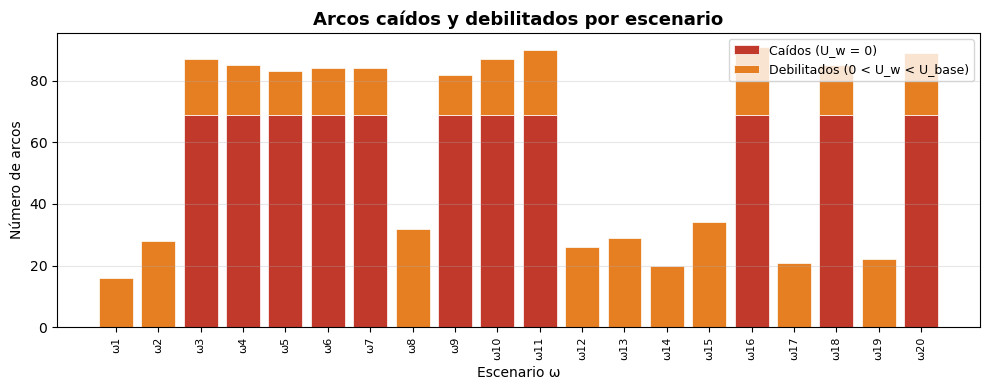

In [68]:
# Arcos caídos vs. debilitados

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, arcos_caidos, label="Caídos (U_w = 0)",
       color="#c0392b", edgecolor="white", linewidth=0.5)
ax.bar(labels, arcos_debil, bottom=arcos_caidos,
       label="Debilitados (0 < U_w < U_base)",
       color="#e67e22", edgecolor="white", linewidth=0.5)

ax.set_title("Arcos caídos y debilitados por escenario", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de arcos")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The average percentage of capacity loss per scenario is significantly higher in crisis scenarios. This indicates that disruptions such as outages or degraded transmission lines reduce the effective capacity of the network. Normal scenarios show relatively small capacity losses, while crisis scenarios exhibit substantial degradation, which directly limits power flow across the network.

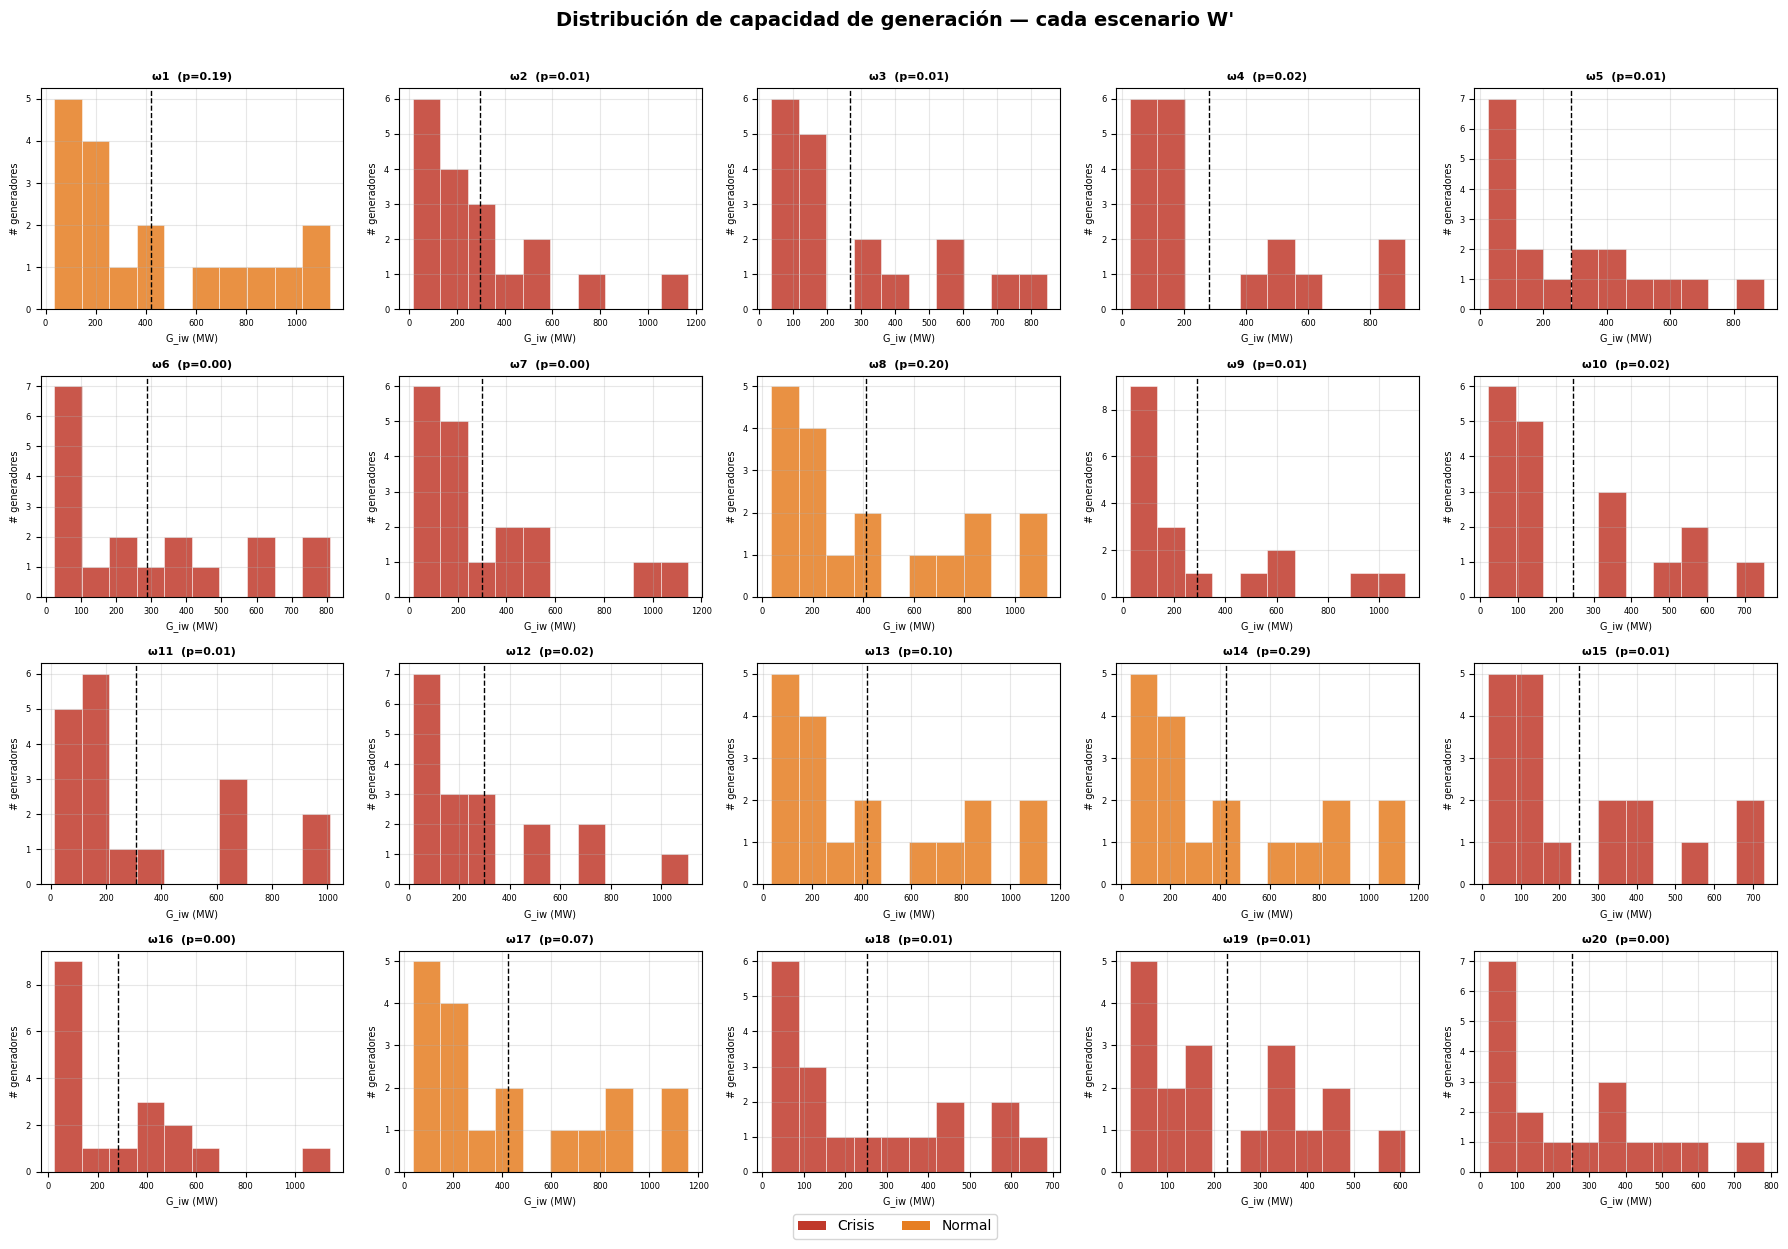

In [69]:
# Generación

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

# solo nodos generadores
gen_nodes_list = nodes[nodes["is_generator"] == True]["node"].tolist()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    # solo filas de generadores
    vals = dfG[(dfG["omega"] == w) & (dfG["node"].isin(gen_nodes_list))]["G_iw"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#e67e22"

    ax.hist(vals, bins=10, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("G_iw (MW)", fontsize=7)
    ax.set_ylabel("# generadores", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de capacidad de generación — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
gen_legend = [Patch(facecolor="#c0392b", label="Crisis"),
              Patch(facecolor="#e67e22", label="Normal")]
fig.legend(handles=gen_legend, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

Crisis scenarios tend to show lower and more dispersed generation levels, suggesting that some generators operate below their nominal capacity during disruptions. Normal scenarios remain more concentrated, indicating a more stable and reliable generation supply.

In [70]:
# -------------------------
# Tabla resumen por escenario
# -------------------------

# Demanda total por escenario
demanda_total = (
    dfD.groupby("omega")["D_iw"]
    .sum()
    .reset_index()
)

# Capacidad total por escenario
capacidad_total = (
    dfU.groupby("omega")["U_ew"]
    .sum()
    .reset_index()
)

# Indicador de crisis
# (ajusta el nombre si tu columna se llama distinto)
crisis_df = (
    dfp[["omega", "crisis"]]
    .copy()
)

# Merge
scenario_table = (
    demanda_total
    .merge(crisis_df, on="omega")
    .merge(capacidad_total, on="omega")
)

# Gap demanda-capacidad
scenario_table["gap_demanda_capacidad"] = (
    scenario_table["D_iw"]
    - scenario_table["U_ew"]
)

# Ordenar por demanda descendente
scenario_table = scenario_table.sort_values(
    "D_iw",
    ascending=False
)

# Renumerar índices
scenario_table = scenario_table.reset_index(drop=True)

# Mostrar
display(scenario_table)

,omega,D_iw,crisis,U_ew,gap_demanda_capacidad
0,16,7727.265539,1,49595.40,-41868.134461
1,7,7182.845038,1,50712.25,-43529.404962
2,6,6470.685322,1,49889.40,-43418.714678
3,3,6057.131420,1,50474.95,-44417.818580
4,11,5842.373764,1,50339.15,-44496.776236
5,15,5634.335983,1,77018.40,-71384.064017
6,5,5510.295254,1,51249.15,-45738.854746
7,18,5413.078934,1,45516.15,-40103.071066
8,12,5282.637396,1,78512.90,-73230.262604
9,2,5158.100590,1,77830.05,-72671.949410
